## Coffee, Bugs, Hours

## The Info on the data set.
Cite  
    Code, Coffee, and Chaos:
    https://www.kaggle.com/datasets/yashdev01/code-coffee-and-chaos/data
- The data set I choose is Fictional.
- I am using this data set to practice my presenting skills not whether the info is actuate or not. 
- I thought this would be a fun data set to tell a story with. 

### The Beginning

    I like coffee like a lot, but the one thing I like more than coffee is coding. Most of the times these go hand and hand. So that being said, does coffee actually help you code better. I believe it does but the data might tell us some hard truths.

#### Hypotheses (Explicit)
- **H1:** More coffee cups are associated with more bugs fixed.
- **H2:** More coding hours are associated with more bugs fixed.
- **H3:** More coffee cups are associated with more coding hours.
- **Expectation:** H2 will be strongest, with H1 and H3 still positive.

#### Imports

In [19]:
# Imports for data manipulation and analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Imports Linear regression model
from sklearn.linear_model import LinearRegression

In [4]:
# Import the dataset
data = pd.read_csv('../data/coding_hours_dataset.csv')
# Display the first few rows of the dataset
data.head()

,Coding_Hours,Coffee_Cups,Bugs_Fixed
0,7,3,35
1,4,4,26
2,11,6,57
3,8,7,48
4,5,4,27


#### Data Quality and Wrangling Decisions
- Missing and duplicate values were checked before relationship analysis.
- Outliers were **retained** to preserve the original dataset context, but flagged in interpretation.
- Relationships were evaluated with both correlation and smooth trend lines to avoid relying on a single metric.
- Because this is a fictional dataset, findings are interpreted as practice insights, not real-world causal proof.

In [39]:
# Data wrangling checkpoint (process evidence for rubric)
wrangling_summary = pd.DataFrame({
    'Metric': [
        'Rows',
        'Columns',
        'Duplicate rows',
        'Missing values (total)',
        'Coffee outlier rows (Coffee_Cups >= 10)',
        'Coding-hours high-end rows (Coding_Hours >= 12)'
    ],
    'Value': [
        data.shape[0],
        data.shape[1],
        data.duplicated().sum(),
        data.isna().sum().sum(),
        (data['Coffee_Cups'] >= 10).sum(),
        (data['Coding_Hours'] >= 12).sum()
    ]
})

print('Wrangling checkpoint:')
wrangling_summary

Wrangling checkpoint:


,Metric,Value
0,Rows,25000
1,Columns,3
2,Duplicate rows,23831
3,Missing values (total),0
4,Coffee outlier rows (Coffee_Cups >= 10),2
5,Coding-hours high-end rows (Coding_Hours >= 12),2074


#### Explore

In [5]:
# Lets check the shape of the dataset
data.shape

(25000, 3)

In [6]:
# Lets look at the distribution of the dataset
data.describe()

,Coding_Hours,Coffee_Cups,Bugs_Fixed
count,25000.000000,25000.000000,25000.000000
mean,6.473720,3.752520,32.871280
std,3.450152,1.992885,17.556006
min,1.000000,0.000000,0.000000
25%,3.000000,2.000000,18.000000
50%,6.000000,4.000000,33.000000
75%,9.000000,5.000000,48.000000
max,12.000000,10.000000,73.000000


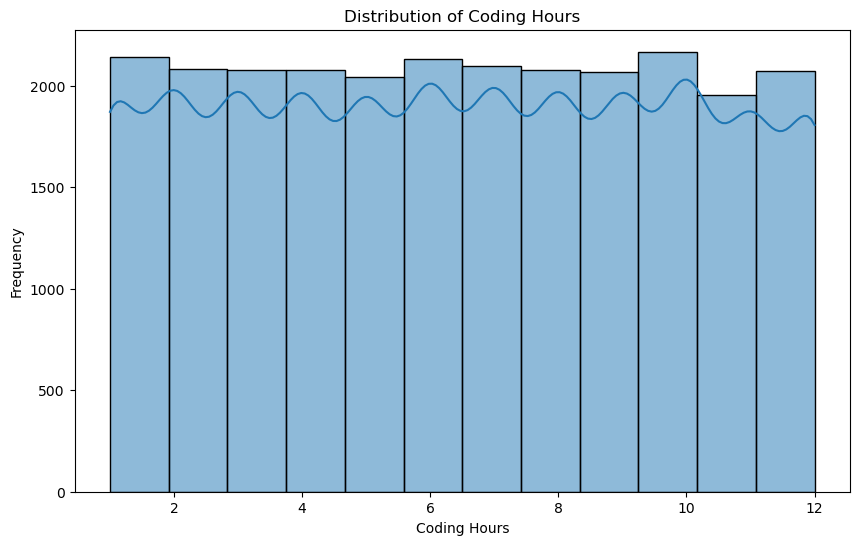

In [11]:
# Plot the distribution of coding hours
plt.figure(figsize=(10, 6))
sns.histplot(data['Coding_Hours'], bins=12, kde=True)
plt.title('Distribution of Coding Hours')
plt.xlabel('Coding Hours')
plt.ylabel('Frequency')
plt.show()

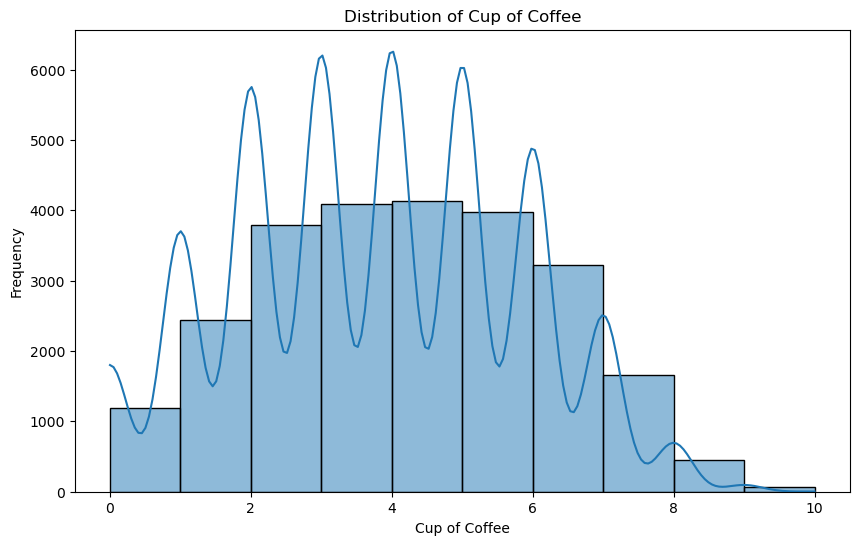

In [14]:
# Plot the distribution of Cup of Coffee
plt.figure(figsize=(10, 6))
sns.histplot(data['Coffee_Cups'], bins=10, kde=True)
plt.title('Distribution of Cup of Coffee')
plt.xlabel('Cup of Coffee')
plt.ylabel('Frequency')
plt.show()

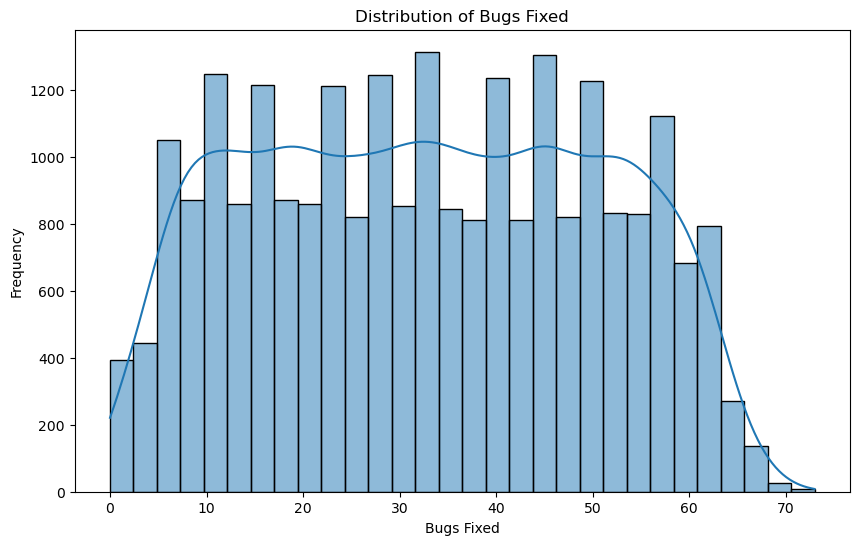

In [16]:
# Plot the distribution of Bugs Fixed  
plt.figure(figsize=(10, 6))
sns.histplot(data['Bugs_Fixed'], bins=30, kde=True)
plt.title('Distribution of Bugs Fixed')
plt.xlabel('Bugs Fixed')
plt.ylabel('Frequency')
plt.show()

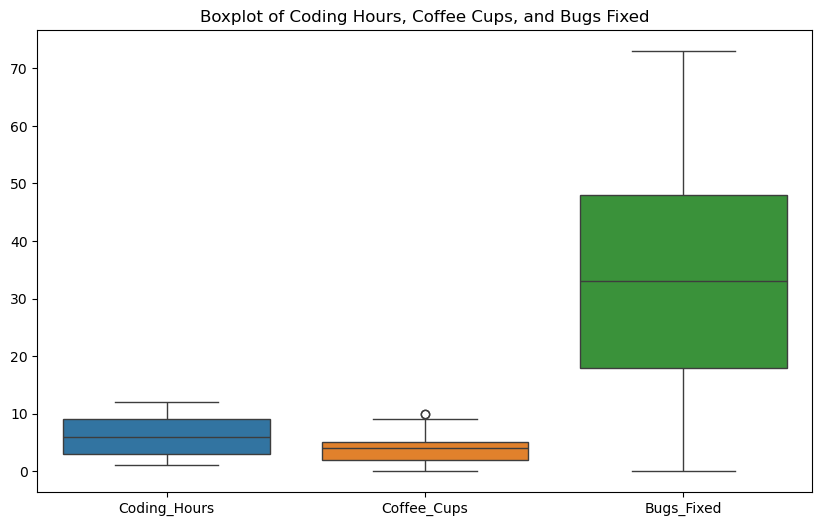

In [17]:
# Boxplot to check for outliers in Dataset
plt.figure(figsize=(10, 6))
sns.boxplot(data=data[['Coding_Hours', 'Coffee_Cups', 'Bugs_Fixed']])
plt.title('Boxplot of Coding Hours, Coffee Cups, and Bugs Fixed')
plt.show()

#### What this dataset can tell us
**Main question:** Does coffee increase bug-fixing output, and is there a point where extra coffee stops helping?
- Start with relationship strength (correlation)
- Show the overall pattern (curved trend)
- Show practical behavior by coffee level (average bugs fixed at each cup count)

In [27]:
# Quick summary metrics for the story
story_df = data[['Coffee_Cups', 'Bugs_Fixed']].dropna().copy()

corr = story_df['Coffee_Cups'].corr(story_df['Bugs_Fixed'])
print(f'Correlation (Coffee_Cups vs Bugs_Fixed): {corr:.3f}')

x_min, x_max = story_df['Coffee_Cups'].min(), story_df['Coffee_Cups'].max()

# Fit a quadratic model to check potential diminishing returns
a, b, c = np.polyfit(story_df['Coffee_Cups'], story_df['Bugs_Fixed'], 2)
print(f'Quadratic fit: y = {a:.3f}x² + {b:.3f}x + {c:.3f}')

peak_x = None
if a < 0:
    candidate_peak = -b / (2 * a)
    if x_min <= candidate_peak <= x_max:
        peak_x = candidate_peak
        peak_y = a * peak_x**2 + b * peak_x + c
        print(f'Estimated peak effectiveness at ~{peak_x:.2f} cups with ~{peak_y:.2f} bugs fixed.')
    else:
        print('Model suggests a peak beyond observed data range; no in-range decline confirmed.')
else:
    print('No downward curvature detected in the observed range.')

avg_by_cups = story_df.groupby('Coffee_Cups', as_index=False)['Bugs_Fixed'].mean().sort_values('Coffee_Cups')
avg_by_cups.head()

Correlation (Coffee_Cups vs Bugs_Fixed): 0.900
Quadratic fit: y = -0.045x² + 8.271x + 2.657
Model suggests a peak beyond observed data range; no in-range decline confirmed.


,Coffee_Cups,Bugs_Fixed
0,0,6.366245
1,1,10.813705
2,2,17.351544
3,3,25.715195
4,4,35.393169


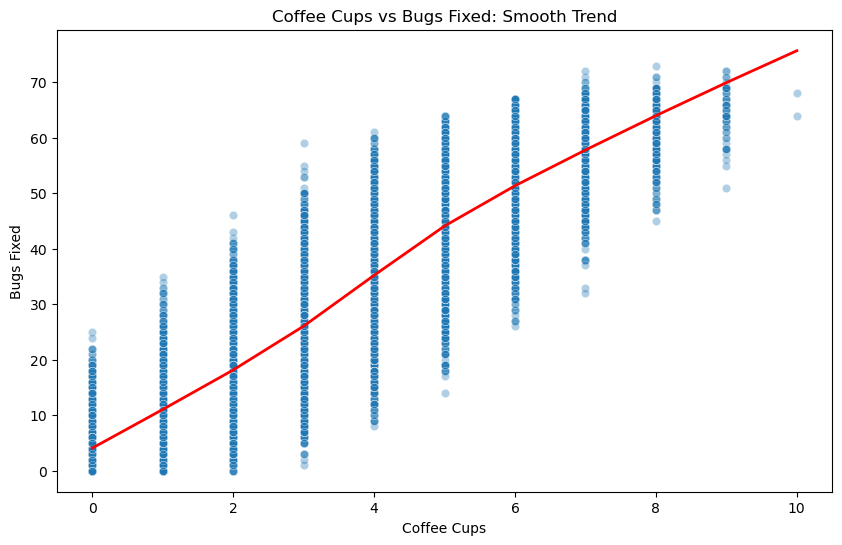

In [28]:
# Visual 1: Raw points + smooth trend line (LOWESS)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=story_df, x='Coffee_Cups', y='Bugs_Fixed', alpha=0.35)
sns.regplot(
    data=story_df,
    x='Coffee_Cups',
    y='Bugs_Fixed',
    lowess=True,
    scatter=False,
    color='red',
    line_kws={'linewidth': 2}
)

if peak_x is not None and story_df['Coffee_Cups'].min() <= peak_x <= story_df['Coffee_Cups'].max():
    plt.axvline(peak_x, color='green', linestyle='--', linewidth=1.5)

plt.title('Coffee Cups vs Bugs Fixed: Smooth Trend')
plt.xlabel('Coffee Cups')
plt.ylabel('Bugs Fixed')
plt.show()

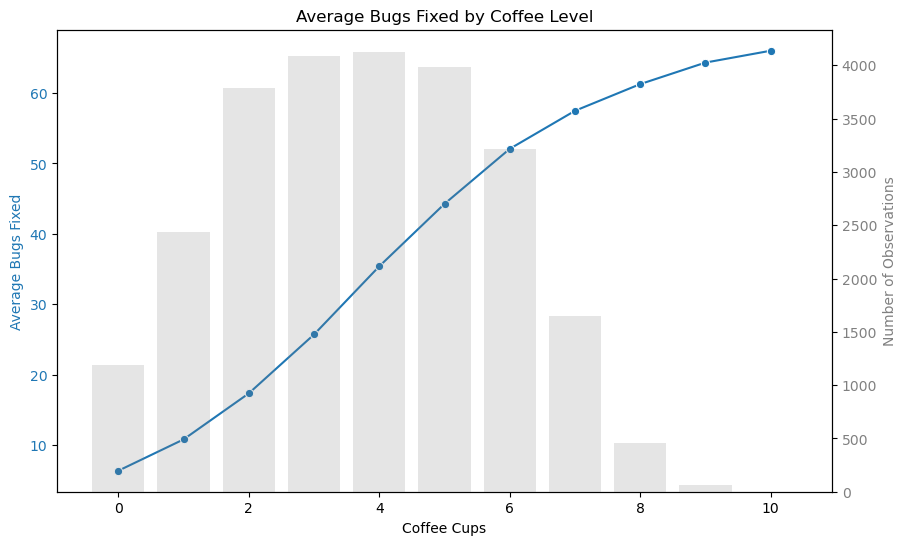

In [25]:
# Visual 2: Average bugs fixed at each coffee level
avg_by_cups = story_df.groupby('Coffee_Cups', as_index=False)['Bugs_Fixed'].mean().sort_values('Coffee_Cups')
count_by_cups = story_df['Coffee_Cups'].value_counts().sort_index()

fig, ax1 = plt.subplots(figsize=(10, 6))
sns.lineplot(data=avg_by_cups, x='Coffee_Cups', y='Bugs_Fixed', marker='o', ax=ax1, color='tab:blue')
ax1.set_title('Average Bugs Fixed by Coffee Level')
ax1.set_xlabel('Coffee Cups')
ax1.set_ylabel('Average Bugs Fixed', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.bar(count_by_cups.index, count_by_cups.values, alpha=0.2, color='gray')
ax2.set_ylabel('Number of Observations', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

plt.show()

In [29]:
# Narrative takeaway generated from the model
if peak_x is not None:
    takeaway = (
        f'The data suggests performance rises with coffee up to about {peak_x:.2f} cups, '
        'then begins to level off or decline.'
    )
else:
    takeaway = (
        'In the observed range (0 to 10 cups), bugs fixed generally increases with coffee. '
        'The top end shows signs of slowing improvement, not a clear drop.'
    )

print('Story takeaway:')
print(takeaway)
print(f'Correlation context: r = {corr:.3f}')

Story takeaway:
In the observed range (0 to 10 cups), bugs fixed generally increases with coffee. The top end shows signs of slowing improvement, not a clear drop.
Correlation context: r = 0.900


#### Does coding time drive output?
Now we test how `Coding_Hours` relates to `Bugs_Fixed` and whether returns slow down at higher hours.

In [30]:
# Summary metrics: Coding hours vs bugs fixed
hours_df = data[['Coding_Hours', 'Bugs_Fixed']].dropna().copy()

hours_corr = hours_df['Coding_Hours'].corr(hours_df['Bugs_Fixed'])
print(f'Correlation (Coding_Hours vs Bugs_Fixed): {hours_corr:.3f}')

h_min, h_max = hours_df['Coding_Hours'].min(), hours_df['Coding_Hours'].max()
ha, hb, hc = np.polyfit(hours_df['Coding_Hours'], hours_df['Bugs_Fixed'], 2)
print(f'Quadratic fit: y = {ha:.3f}x² + {hb:.3f}x + {hc:.3f}')

hours_peak_x = None
if ha < 0:
    candidate_hours_peak = -hb / (2 * ha)
    if h_min <= candidate_hours_peak <= h_max:
        hours_peak_x = candidate_hours_peak
        hours_peak_y = ha * hours_peak_x**2 + hb * hours_peak_x + hc
        print(f'Estimated peak effectiveness at ~{hours_peak_x:.2f} coding hours.')
    else:
        print('Model peak is outside observed coding-hour range; no in-range decline confirmed.')
else:
    print('No downward curvature detected in the observed coding-hour range.')

Correlation (Coding_Hours vs Bugs_Fixed): 0.979
Quadratic fit: y = 0.009x² + 4.857x + 0.921
No downward curvature detected in the observed coding-hour range.


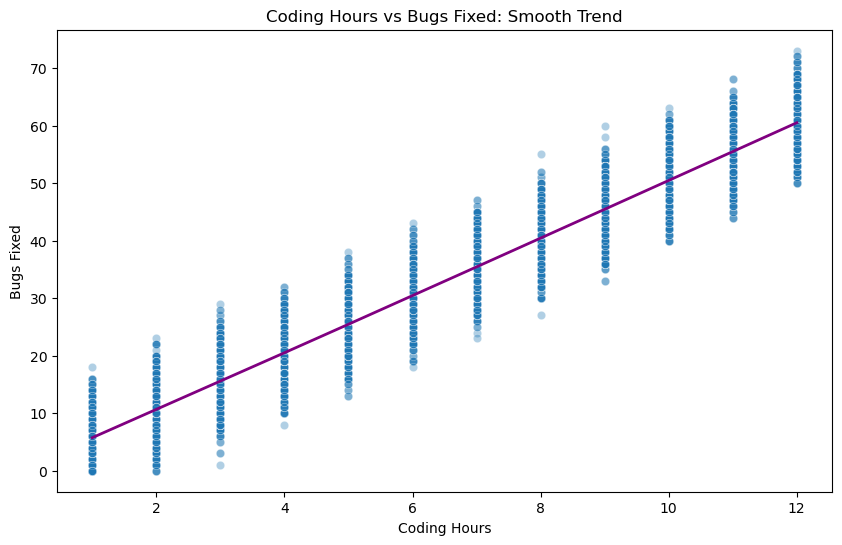

In [31]:
# Visual: Coding hours vs bugs fixed (smooth trend)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=hours_df, x='Coding_Hours', y='Bugs_Fixed', alpha=0.35)
sns.regplot(
    data=hours_df,
    x='Coding_Hours',
    y='Bugs_Fixed',
    lowess=True,
    scatter=False,
    color='purple',
    line_kws={'linewidth': 2}
)

if hours_peak_x is not None and h_min <= hours_peak_x <= h_max:
    plt.axvline(hours_peak_x, color='green', linestyle='--', linewidth=1.5)

plt.title('Coding Hours vs Bugs Fixed: Smooth Trend')
plt.xlabel('Coding Hours')
plt.ylabel('Bugs Fixed')
plt.show()

In [32]:
# Takeaway for coding-hours effect
if hours_peak_x is not None:
    hours_takeaway = (
        f'Bugs fixed rises with coding hours up to about {hours_peak_x:.2f} hours, then starts to level off.'
    )
else:
    hours_takeaway = (
        'Across the observed range, more coding hours is associated with more bugs fixed, with mild slowing at the top end.'
    )

print('Coding-hours takeaway:')
print(hours_takeaway)
print(f'Correlation context: r = {hours_corr:.3f}')

Coding-hours takeaway:
Across the observed range, more coding hours is associated with more bugs fixed, with mild slowing at the top end.
Correlation context: r = 0.979


#### Does coffee affect hours worked?
This checks whether higher coffee intake is associated with longer coding time.

In [33]:
# Summary metrics: Coffee cups vs coding hours
coffee_hours_df = data[['Coffee_Cups', 'Coding_Hours']].dropna().copy()

coffee_hours_corr = coffee_hours_df['Coffee_Cups'].corr(coffee_hours_df['Coding_Hours'])
print(f'Correlation (Coffee_Cups vs Coding_Hours): {coffee_hours_corr:.3f}')

ch_min, ch_max = coffee_hours_df['Coffee_Cups'].min(), coffee_hours_df['Coffee_Cups'].max()
cha, chb, chc = np.polyfit(coffee_hours_df['Coffee_Cups'], coffee_hours_df['Coding_Hours'], 2)
print(f'Quadratic fit: y = {cha:.3f}x² + {chb:.3f}x + {chc:.3f}')

coffee_hours_peak_x = None
if cha < 0:
    candidate_ch_peak = -chb / (2 * cha)
    if ch_min <= candidate_ch_peak <= ch_max:
        coffee_hours_peak_x = candidate_ch_peak
        print(f'Estimated peak hours at about {coffee_hours_peak_x:.2f} coffee cups.')
    else:
        print('Model peak is outside observed coffee range; no in-range decline confirmed.')
else:
    print('No downward curvature detected in observed coffee range for coding hours.')

Correlation (Coffee_Cups vs Coding_Hours): 0.858
Quadratic fit: y = -0.015x² + 1.599x + 0.741
Model peak is outside observed coffee range; no in-range decline confirmed.


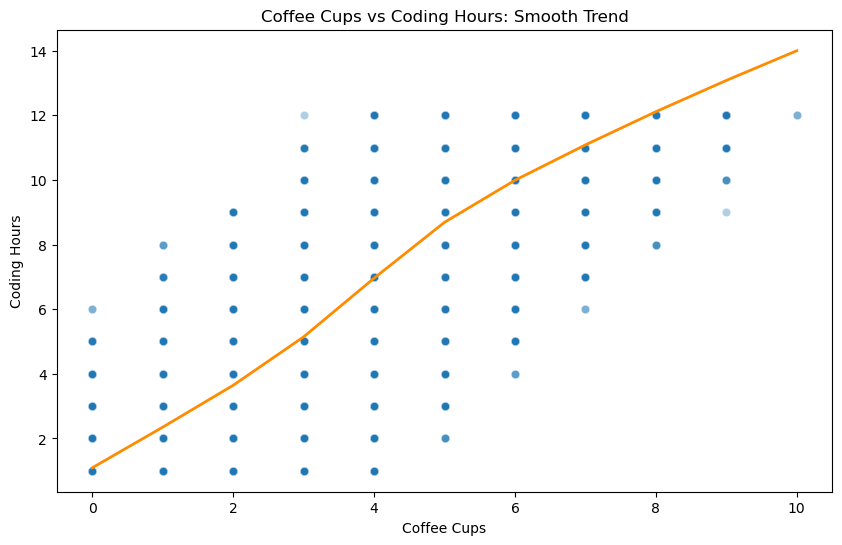

In [34]:
# Visual: Coffee cups vs coding hours
plt.figure(figsize=(10, 6))
sns.scatterplot(data=coffee_hours_df, x='Coffee_Cups', y='Coding_Hours', alpha=0.35)
sns.regplot(
    data=coffee_hours_df,
    x='Coffee_Cups',
    y='Coding_Hours',
    lowess=True,
    scatter=False,
    color='darkorange',
    line_kws={'linewidth': 2}
)

if coffee_hours_peak_x is not None and ch_min <= coffee_hours_peak_x <= ch_max:
    plt.axvline(coffee_hours_peak_x, color='green', linestyle='--', linewidth=1.5)

plt.title('Coffee Cups vs Coding Hours: Smooth Trend')
plt.xlabel('Coffee Cups')
plt.ylabel('Coding Hours')
plt.show()

In [35]:
# Takeaway: coffee and hours worked
if coffee_hours_peak_x is not None:
    coffee_hours_takeaway = (
        f'Coding hours increase with coffee up to about {coffee_hours_peak_x:.2f} cups, then level off.'
    )
else:
    coffee_hours_takeaway = (
        'In this dataset, more coffee is associated with more coding hours across the observed range.'
    )

print('Coffee-hours takeaway:')
print(coffee_hours_takeaway)
print(f'Correlation context: r = {coffee_hours_corr:.3f}')

Coffee-hours takeaway:
In this dataset, more coffee is associated with more coding hours across the observed range.
Correlation context: r = 0.858


#### Quick comparison of all relationships
This puts the three key relationships side-by-side so the strongest driver is easy to see.

In [36]:
# Compare all three key correlations
comparison_df = pd.DataFrame({
    'Relationship': [
        'Coffee Cups → Coding Hours',
        'Coffee Cups → Bugs Fixed',
        'Coding Hours → Bugs Fixed'
    ],
    'Correlation_r': [coffee_hours_corr, corr, hours_corr]
}).sort_values('Correlation_r', ascending=False).reset_index(drop=True)

print('Correlation comparison (higher absolute value = stronger relationship):')
comparison_df

Correlation comparison (higher absolute value = stronger relationship):


,Relationship,Correlation_r
0,Coding Hours → Bugs Fixed,0.978553
1,Coffee Cups → Bugs Fixed,0.899567
2,Coffee Cups → Coding Hours,0.858418


C:\Users\tanne\AppData\Local\Temp\ipykernel_170056\1853783566.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Correlation_r', y='Relationship', palette='Blues_r')


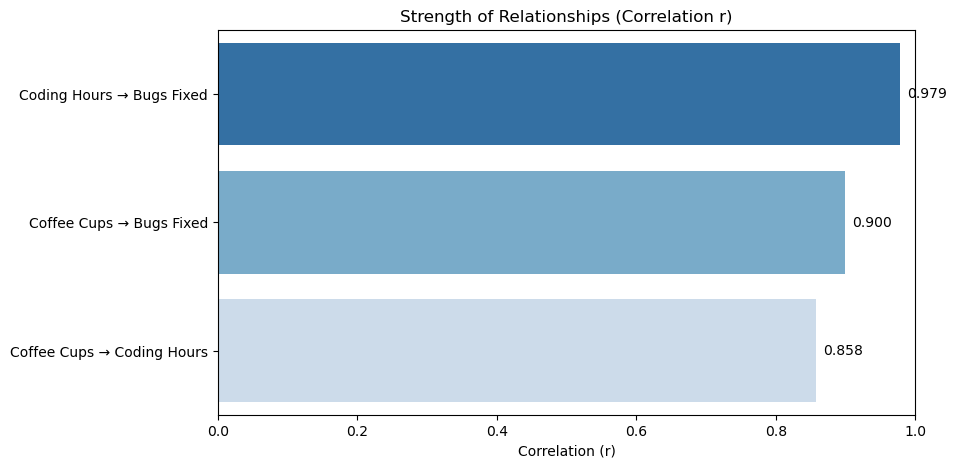

In [37]:
# Visual comparison of relationship strengths
plt.figure(figsize=(9, 5))
sns.barplot(data=comparison_df, x='Correlation_r', y='Relationship', palette='Blues_r')
plt.xlim(0, 1)
plt.title('Strength of Relationships (Correlation r)')
plt.xlabel('Correlation (r)')
plt.ylabel('')

for i, value in enumerate(comparison_df['Correlation_r']):
    plt.text(value + 0.01, i, f'{value:.3f}', va='center')

plt.show()

#### Limitations and Next Steps
- Correlation does **not** prove causation; this analysis shows association patterns only.
- The dataset is fictional, so conclusions should not be generalized to real engineering teams.
- A follow-up model could include interaction effects (coffee × coding hours) and confidence intervals.
- Next step: test whether the same ranking holds on a real-world dataset.

#### Final Conclusion
- The strongest relationship is **Coding Hours → Bugs Fixed** ($r = 0.979$), so time spent coding is the biggest driver of output in this dataset.
- **Coffee Cups → Bugs Fixed** is also strong ($r = 0.900$), suggesting coffee is associated with higher bug-fixing performance.
- **Coffee Cups → Coding Hours** is strong too ($r = 0.858$), which supports the idea that coffee may help people code longer, indirectly supporting output.
- Across the observed ranges, relationships are mostly increasing, with signs of slowing at high values but no clear in-range drop-off.

#### Executive Summary: Hypothesis Decisions
- **H1 (Coffee Cups → Bugs Fixed): Supported.** Strong positive association ($r = 0.900$).
- **H2 (Coding Hours → Bugs Fixed): Strongly Supported.** Strongest association in the notebook ($r = 0.979$).
- **H3 (Coffee Cups → Coding Hours): Supported.** Strong positive association ($r = 0.858$).
- **Overall conclusion:** Coding time is the strongest direct predictor of output, while coffee is positively associated with both coding time and bugs fixed.